In [ ]:
import pandas as pd
from pathlib import Path

basepath = Path.cwd()

filepath = basepath / 'cleaned_data.parquet'

df = pd.read_parquet(filepath)
df.head()

#identify duplicate 
#duplicated = df[df.duplicated()]
# print(duplicated)

# -- remove duplicates ---
df = df.drop_duplicates()

#check dtypes
# df.dtypes


df= df.dropna(subset='nutrition_grade')

drop_list = ['unknown', 'not applicable']

# The ~ means "is NOT in"
df = df[~df['nutrition_grade'].isin(drop_list)]

#fill nulls with means
df = df.fillna(df.mean(numeric_only= True))

#sugars > carb 
df = df.query('sugars <= carbohydrates')

df['healthy_ind'] = df['nutrition_grade'].apply(
    lambda x: 1 if x in ['a','b'] else 0
)











<Axes: ylabel='Frequency'>

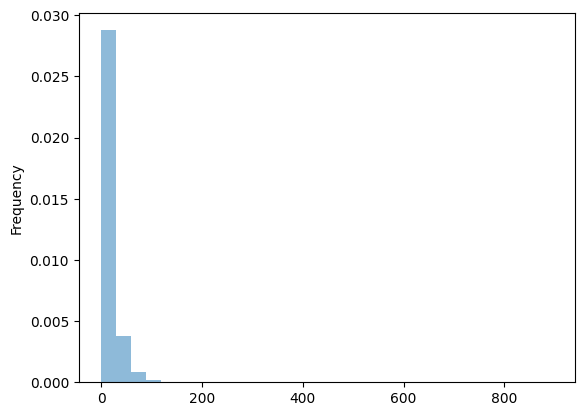

In [25]:
import matplotlib as plt

#df.describe(include = 'number')

df['sugars'].plot(kind='hist', density=True, bins=30, alpha=0.5)


In [52]:
df['healthy_ind'].value_counts(normalize= True)

healthy_ind
0    0.677302
1    0.322698
Name: proportion, dtype: float64